# 实验八：拉格朗日乘子法与 KKT 条件的局限性

## 知识背景回顾

在前面的实验和学习中（教材 4.6 节），我们掌握了使用拉格朗日乘子法和 KKT 条件来求解约束优化问题的核心思想：通过引入拉格朗日乘子，将约束问题转化为求解一个方程（和不等式）组，即寻找满足 KKT 条件的点。

回顾 KKT 条件（以 $\min f(x)$ s.t. $g_i(x) \ge 0, h_j(x) = 0$ 为例）：
1.  **平稳性:** $\nabla f(x^*) - \sum \mu_i^* \nabla g_i(x^*) + \sum \lambda_j^* \nabla h_j(x^*) = 0$
2.  **原始可行性:** $g_i(x^*) \ge 0$, $h_j(x^*) = 0$
3.  **对偶可行性:** $\mu_i^* \ge 0$
4.  **互补松弛性:** $\mu_i^* g_i(x^*) = 0$

这些条件在很多情况下非常有效，特别是对于**凸优化问题**。在凸优化问题中（并满足如 Slater 等条件时），KKT 条件通常既是**必要条件**也是**充分条件**，意味着找到 KKT 点就找到了全局最优解。

然而，在更一般的情况下，KKT 条件的应用存在一些需要注意的局限性：
* **非凸问题**: 当优化问题不是凸的（例如目标函数非凸，或可行域非凸），KKT 条件仅仅是**必要条件**。这意味着，满足 KKT 条件的点**不一定**是局部最小值，它可能是局部最大值或鞍点。我们必须使用其他方法（如二阶条件或比较函数值）来进一步判断。
* **约束规范 (Constraint Qualification, CQ)**: KKT 条件的理论推导需要满足一定的**约束规范**条件（也称正则性条件）。一个常用的条件是 LICQ (Linear Independence Constraint Qualification)，即在最优点处，所有**激活**的不等式约束 $g_i(x^*)=0$ 和所有等式约束 $h_j(x^*)=0$ 的梯度向量必须是**线性无关**的。如果约束规范不满足，那么真正的最优点**可能根本不满足 KKT 条件**，这时 KKT 方法可能会“失效”或“遗漏”最优解。

## 实验说明

本次实验将通过两个具体的算例，可视化地展示 KKT 条件的上述两种局限性。

### 模块一：非凸问题下的 KKT 点

* **目标**: 展示在一个非凸优化问题中，一个满足 KKT 条件的点可能并非局部最小值。
* **算例**: 我们将考虑一个目标函数包含正弦波动的非凸问题，约束在一个单位圆盘内。
    * $\min f(x, y) = \sin(\pi x) + y^2$
    * s.t. $g(x, y) = 1 - x^2 - y^2 \ge 0$
* **分析**: 我们将首先通过数学推导找出所有满足 KKT 条件的点。然后，通过绘制函数等高线、可行域以及标记这些 KKT 点，直观地判断哪些点是局部最小值、哪些不是（可能是局部最大值或鞍点）。
* **观察重点**:
    * 确认图中标记的所有点都满足 KKT 条件（可以通过检查梯度关系、约束状态和乘子符号来理解）。
    * 通过等高线判断，哪个（些）KKT 点是真正的局部最小值？哪个（些）不是？
    * 理解为什么 KKT 条件在这种非凸情况下只能“筛选”出候选点，而不能保证找到的都是最小值。

### 模块二：约束规范不满足导致 KKT 失效

* **目标**: 展示在一个约束规范不满足的例子中，真正的最优点无法通过求解 KKT 系统找到。
* **算例**: 我们考虑一个寻找两个相互外切的圆盘交点（只有一个交点）处某个函数最小值的问题。在切点处，两个约束的梯度是线性相关的，不满足 LICQ。
    * $\min f(x, y) = y$
    * s.t. $g_1(x, y) = 1 - (x-1)^2 - y^2 \ge 0$ （圆心(1,0), 半径1）
    * s.t. $g_2(x, y) = 1 - (x+1)^2 - y^2 \ge 0$ （圆心(-1,0), 半径1）
* **分析**: 这个问题只有一个可行点 $(0,0)$，因此它就是全局最小值点，最优值 $f(0,0)=0$。我们将计算在 $(0,0)$ 点处，目标函数和两个约束函数的梯度。然后，我们将尝试应用 KKT 的平稳性条件，看是否存在非负乘子 $\mu_1^*, \mu_2^*$ 使得 $\nabla f(0,0) - \mu_1^* \nabla g_1(0,0) - \mu_2^* \nabla g_2(0,0) = 0$ 成立。
* **观察重点**:
    * 确认 $(0,0)$ 是唯一的可行点和最优解。
    * 观察在 $(0,0)$ 点，两个约束的梯度 $\nabla g_1$ 和 $\nabla g_2$ 的方向关系（它们是线性相关的）。
    * 验证 KKT 的平稳性条件 $\nabla f = \mu_1 \nabla g_1 + \mu_2 \nabla g_2$ 在 $(0,0)$ 点无法被满足（找不到合适的 $\mu_1 \ge 0, \mu_2 \ge 0$）。
    * 理解为什么约束规范（梯度线性无关）对于 KKT 条件的必要性至关重要。

通过这两个案例，你将更深入地理解 KKT 条件的适用范围和潜在的“陷阱”.

--- 模块一：非凸问题下的 KKT 点 ---


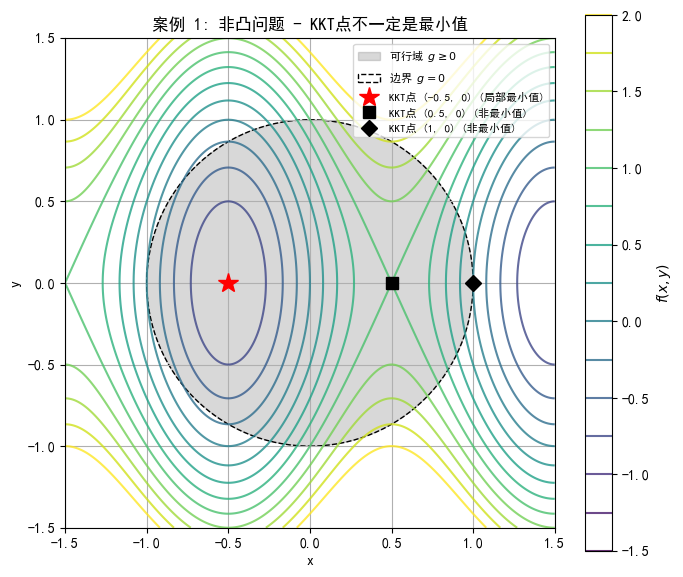

In [1]:
# 实验八：拉格朗日乘子法与 KKT 条件的局限性

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import fsolve # 用于数值求解KKT点（可选）

# --- Matplotlib 设置 ---
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print("--- 模块一：非凸问题下的 KKT 点 ---")

# --- 1. 定义函数和梯度 ---
def f_nonconvex(x, y):
    return np.sin(np.pi * x) + y**2

def grad_f_nonconvex(x, y):
    return np.array([np.pi * np.cos(np.pi * x), 2 * y])

def g_disk(x, y):
    return 1 - x**2 - y**2

def grad_g_disk(x, y):
    # 注意 KKT 公式用的是 g>=0, L = f - mu*g
    # 这里的 grad_g 对应 KKT 中的 nabla g
    return np.array([-2*x, -2*y])

# --- 2. 绘制图形 ---
fig1, ax1 = plt.subplots(figsize=(7, 6))

x_grid = np.linspace(-1.5, 1.5, 400)
y_grid = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z_f = f_nonconvex(X, Y)
Z_g = g_disk(X, Y)

# 绘制等高线
contour = ax1.contour(X, Y, Z_f, levels=np.linspace(-1.5, 2, 15), cmap='viridis', alpha=0.8)
fig1.colorbar(contour, label='$f(x,y)$')

# 绘制可行域 (圆盘)
feasible_region = patches.Circle((0, 0), 1, color='gray', alpha=0.3, label='可行域 $g \geq 0$')
ax1.add_patch(feasible_region)
boundary_circle = patches.Circle((0, 0), 1, edgecolor='k', linestyle='--', facecolor='none', label='边界 $g=0$')
ax1.add_patch(boundary_circle)

# --- 3. 标记 KKT 点 (根据知识背景分析得到) ---
# KKT 点推导:
# L = sin(pi*x) + y^2 - mu*(1 - x^2 - y^2)
# dL/dx = pi*cos(pi*x) - mu*(-2*x) = 0
# dL/dy = 2*y - mu*(-2*y) = 2*y*(1+mu) = 0
# mu >= 0, g >= 0, mu*g = 0
#
# From dL/dy=0: y=0 (since 1+mu > 0)
#
# Case 1: mu = 0 (Internal points)
#   y=0. pi*cos(pi*x)=0 => pi*x = +/- pi/2, +/- 3*pi/2 ... => x = +/- 0.5, +/- 1.5 ...
#   Check g>=0: 1 - x^2 - y^2 >= 0 => 1 - x^2 >= 0 => |x| <= 1
#   Internal KKT points: (0.5, 0) and (-0.5, 0)
#
# Case 2: g = 0 (Boundary points)
#   y=0. 1 - x^2 - y^2 = 0 => x^2 = 1 => x = +/- 1
#   Need mu >= 0.
#   If x=1, y=0: pi*cos(pi) + 2*mu*(1) = 0 => -pi + 2*mu = 0 => mu = pi/2 >= 0. Valid. KKT point: (1, 0)
#   If x=-1, y=0: pi*cos(-pi) + 2*mu*(-1) = 0 => -pi - 2*mu = 0 => mu = -pi/2 < 0. Invalid.
#
# Total KKT points: (0.5, 0), (-0.5, 0), (1, 0)

kkt_points = {
    '(-0.5, 0)': {'coord': (-0.5, 0), 'type': '局部最小值', 'marker': 'r*', 'size': 15},
    '(0.5, 0)':  {'coord': (0.5, 0),  'type': '非最小值', 'marker': 'ks', 'size': 8}, # Saddle or local max
    '(1, 0)':    {'coord': (1, 0),   'type': '非最小值', 'marker': 'kD', 'size': 8}  # Saddle
}

for name, data in kkt_points.items():
    x, y = data['coord']
    ax1.plot(x, y, data['marker'], markersize=data['size'], label=f'KKT点 {name} ({data["type"]})')
    # 可选：绘制梯度
    # nabla_f_p = grad_f_nonconvex(x, y)
    # nabla_g_p = grad_g_disk(x, y)
    # mu_p = ... # Calculate corresponding mu
    # ax1.quiver(x, y, nabla_f_p[0], nabla_f_p[1], color='red', scale=15)
    # if abs(g_disk(x, y)) < 1e-6: # If on boundary
    #     ax1.quiver(x, y, nabla_g_p[0], nabla_g_p[1], color='blue', scale=15)


# --- 4. 设置图形 ---
ax1.set_title('案例 1: 非凸问题 - KKT点不一定是最小值')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)
ax1.grid(True)
ax1.legend(fontsize=8, loc='upper right')
ax1.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


**案例 1 解释:**
此图展示了非凸目标函数 $f(x, y) = \sin(\pi x) + y^2$ 在单位圆盘 $g(x, y) = 1 - x^2 - y^2 \ge 0$ 内的最小化问题。
- **KKT 点:** 我们通过求解 KKT 条件找到了三个候选点：(-0.5, 0), (0.5, 0), 和 (1, 0)。图中用不同标记标出了这些点。
- **观察:**
    - 点 (-0.5, 0) (红星) 位于函数值最低的区域 ($f=-1$)，是局部（也是全局）最小值。它满足 KKT 条件 (内部解，$\nabla f=0, \mu=0$)。
    - 点 (0.5, 0) (黑方块) 位于函数值较高的区域 ($f=1$)，显然不是最小值（实际是一个局部最大值点）。它也满足 KKT 条件 (内部解，$\nabla f=0, \mu=0$)。
    - 点 (1, 0) (黑菱形) 位于边界上 ($f=0$)，也不是最小值。它也满足 KKT 条件（边界解，$\nabla f = \mu \nabla g$, $\mu = \pi/2 > 0$）。
- **结论:** 这个例子清晰地表明，对于非凸问题，KKT 条件仅是**必要条件**。它能帮助我们找到所有可能的**驻点**（包括最小值、最大值和鞍点），但**不能保证**找到的点就是最小值。我们需要进一步的分析（例如比较函数值或检查二阶条件）来确定哪个 KKT 点是真正的最优解。



--- 模块二：约束规范不满足导致 KKT 失效 ---


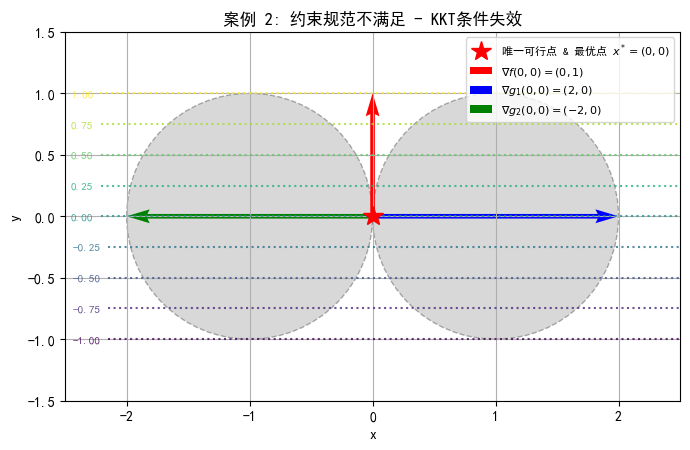

In [2]:
print("\n--- 模块二：约束规范不满足导致 KKT 失效 ---")

# --- 1. 定义函数和梯度 ---
def f_cq(x, y):
    return y

def grad_f_cq(x, y):
    return np.array([0.0, 1.0])

# g1 >= 0
def g1_cq(x, y):
    return 1 - (x - 1)**2 - y**2
def grad_g1_cq(x, y):
    return np.array([-2*(x - 1), -2*y])

# g2 >= 0
def g2_cq(x, y):
    return 1 - (x + 1)**2 - y**2
def grad_g2_cq(x, y):
    return np.array([-2*(x + 1), -2*y])

# --- 2. 绘制图形 ---
fig2, ax2 = plt.subplots(figsize=(7, 6))

x_grid = np.linspace(-2.5, 2.5, 400)
y_grid = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z_f = f_cq(X, Y)
Z_g1 = g1_cq(X, Y)
Z_g2 = g2_cq(X, Y)

# 绘制等高线
contour_f = ax2.contour(X, Y, Z_f, levels=np.linspace(-1, 1, 9), cmap='viridis', alpha=0.8, linestyles='dotted')
ax2.clabel(contour_f, inline=True, fontsize=8)

# 绘制可行域边界 (两个圆)
circle1 = patches.Circle((1, 0), 1, edgecolor='k', linestyle='--', facecolor='gray', alpha=0.3)
ax2.add_patch(circle1)
circle2 = patches.Circle((-1, 0), 1, edgecolor='k', linestyle='--', facecolor='gray', alpha=0.3)
ax2.add_patch(circle2)

# 标记唯一可行点和最优解
opt_point = (0.0, 0.0)
ax2.plot(opt_point[0], opt_point[1], 'r*', markersize=15, label='唯一可行点 & 最优点 $x^*=(0,0)$')

# --- 3. 在最优解处绘制梯度 ---
nabla_f_opt = grad_f_cq(opt_point[0], opt_point[1])
nabla_g1_opt = grad_g1_cq(opt_point[0], opt_point[1])
nabla_g2_opt = grad_g2_cq(opt_point[0], opt_point[1])

ax2.quiver(opt_point[0], opt_point[1], nabla_f_opt[0], nabla_f_opt[1], color='red', scale=5, label=r'$\nabla f(0,0)=(0,1)$')
ax2.quiver(opt_point[0], opt_point[1], nabla_g1_opt[0], nabla_g1_opt[1], color='blue', scale=5, label=r'$\nabla g_1(0,0)=(2,0)$')
ax2.quiver(opt_point[0], opt_point[1], nabla_g2_opt[0], nabla_g2_opt[1], color='green', scale=5, label=r'$\nabla g_2(0,0)=(-2,0)$')

# --- 4. 设置图形 ---
ax2.set_title('案例 2: 约束规范不满足 - KKT条件失效')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_xlim(-2.5, 2.5)
ax2.set_ylim(-1.5, 1.5)
ax2.grid(True)
ax2.legend(fontsize=8, loc='upper right')
ax2.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


**案例 2 解释:**

此图展示了最小化 $f(x, y) = y$ 在两个相互外切的圆盘 $g_1=1-(x-1)^2-y^2 \ge 0$ 和 $g_2=1-(x+1)^2-y^2 \ge 0$ 交集上的问题。

- **可行域与最优解:** 唯一的可行点是两个圆盘的切点 $(0,0)$。因此，$(0,0)$ 自动成为问题的全局最优解，最优值 $f(0,0)=0$。
- **梯度计算:** 在最优点 $(0,0)$ 处：
    - $\nabla f(0,0) = (0, 1)$ (红色箭头)
    - $\nabla g_1(0,0) = (2, 0)$ (蓝色箭头)
    - $\nabla g_2(0,0) = (-2, 0)$ (绿色箭头)
- **约束规范 (LICQ) 检查:** 两个约束 $g_1$ 和 $g_2$ 在最优点 $(0,0)$ 处都激活了 ($g_1=0, g_2=0$)。它们的梯度 $\nabla g_1 = (2,0)$ 和 $\nabla g_2 = (-2,0)$ 是**线性相关**的（方向相反）。因此，约束规范条件 LICQ **不满足**。
- **KKT 平稳性条件验证:** KKT 条件要求存在 $\mu_1^* \ge 0, \mu_2^* \ge 0$ 使得 $\nabla f(0,0) - \mu_1^* \nabla g_1(0,0) - \mu_2^* \nabla g_2(0,0) = 0$。即：
  $(0, 1) - \mu_1^*(2, 0) - \mu_2^*(-2, 0) = (2\mu_2^* - 2\mu_1^*, 1) = (0, 0)$
  第二个分量要求 $1 = 0$，这是**不可能**成立的！
- **结论:** 真正的全局最优点 $(0,0)$ **并不满足** KKT 条件。这是因为约束规范 (LICQ) 在该点失效，导致 KKT 条件的必要性不再成立。这个例子表明，如果约束规范不满足，依赖 KKT 条件求解可能会**遗漏**真正的最优解。在实际应用中，虽然这种情况不常见，但需要注意约束规范是 KKT 理论有效的前提之一。